<a href="https://colab.research.google.com/github/ramvrum/dap-2024/blob/main/les06/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №6. Линейная регрессия

Набор данных Diabetes (Диабет) содержит 442 образца с 10-ю признаками: возраст, пол, индекс массы тела, средний показатель давления крови и шесть измерений сыворотки крови. Целевое значение - количественный показатель прогрессирования заболевания через год после анализов.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Извлечение данных

In [2]:
from sklearn import datasets
diabetes = datasets.load_diabetes()

1. Выведете описание набора данных и наименование признаков.

In [4]:
print(diabetes.DESCR)

print("Названия признаков:", diabetes.feature_names)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Подготовка данных

2. Из загруженного набора данных создайте DataFrame, содержащий как признаки, так и целевое значение. Выведите первые 5 строк набора.

In [5]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

df['target'] = diabetes.target

df.head(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


3. Выведете информацию о типах данных в наборе. Имеются ли в наборе категориальные признаки? Имеются ли в наборе данные имеющие значение null?

In [6]:
print("Информация о типах данных", df.info())

print("\nКоличество пропусков по каждому столбцу:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
Информация о типах данных None

Количество пропусков по каждому столбцу:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


## Исследование данных

4. Постройте матрицу корреляции.

In [8]:
corr_matrix = df.corr()

corr_matrix

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


5. Постройте диаграмму рассеяния целевого значение и признака, коэффициент корреляции которого с  целевым значением, самый высокий.

Признак с наибольшей корреляцией: bmi
Коэффициент корреляции: 0.59


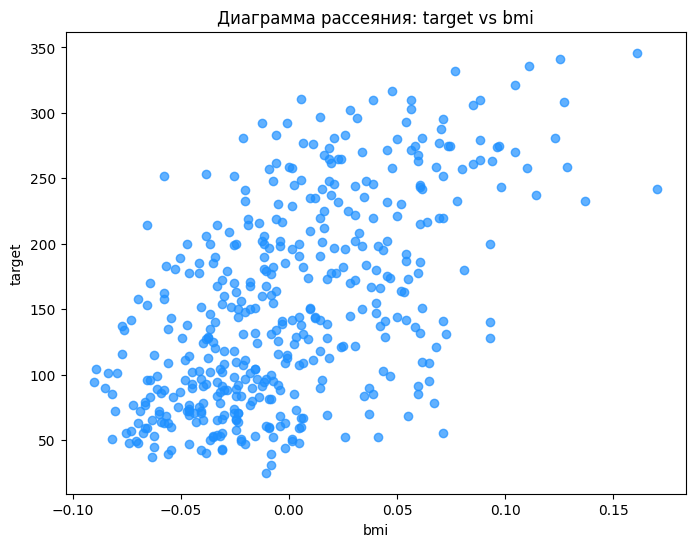

In [9]:
corr_with_target = df.corr()['target'].drop('target')

top_feature = corr_with_target.abs().idxmax()
print(f"Признак с наибольшей корреляцией: {top_feature}")
print(f"Коэффициент корреляции: {corr_with_target[top_feature]:.2f}")

plt.figure(figsize=(8,6))
plt.scatter(df[top_feature], df['target'], color='dodgerblue', alpha=0.7)
plt.xlabel(top_feature)
plt.ylabel('target')
plt.title(f'Диаграмма рассеяния: target vs {top_feature}')
plt.show()

6. Сформируйте набор признаков (X) из 5 признаков с самым высоким коэффициентом корреляции с целевым значением. Сформируйте набор для целевого значения (y).

In [10]:
top5_features = corr_with_target.abs().sort_values(ascending=False).head(5).index
print("5 признаков с наибольшей корреляцией:", list(top5_features))

X = df[top5_features]
y = df['target']

print(X.head())
print(y.head())

5 признаков с наибольшей корреляцией: ['bmi', 's5', 'bp', 's4', 's3']
        bmi        s5        bp        s4        s3
0  0.061696  0.019907  0.021872 -0.002592 -0.043401
1 -0.051474 -0.068332 -0.026328 -0.039493  0.074412
2  0.044451  0.002861 -0.005670 -0.002592 -0.032356
3 -0.011595  0.022688 -0.036656  0.034309 -0.036038
4 -0.036385 -0.031988  0.021872 -0.002592  0.008142
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


## Предсказательная модель

7. Разделите набор данных на два, одни для обучения модели другой для проверки. Тестовый набор должен содержать 25 процентов данных.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов, {X_test.shape[1]} признаков")

Размер обучающей выборки: 331 объектов, 5 признаков
Размер тестовой выборки: 111 объектов, 5 признаков


8. Выполните обучение модели.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Проверка модели

9. Расчитайте Root mean squared error (RMSE)

In [32]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 53.78


10. Расчитайте R² (коэффициент детерминации)

In [34]:
from sklearn import metrics

r2 = metrics.r2_score(y_test, y_pred)
print('R2 =', r2)

R2 = 0.4768642138880054


## Вопросы для защиты

1. Какие типы машинного обучения вы знаете?

Обучение с учителем — модель учится на данных, где уже есть правильные ответы.

Обучение без учителя — модель ищет структуру в данных без правильных ответов.

Обучение с подкреплением — агент учится действовать в среде, получая награды или штрафы за свои действия.

2. Чем отличается обучение с учителем и без учителя?

Обучение с учителем — модель учится на данных, где уже есть правильные ответы.

Обучение без учителя — модель ищет структуру в данных без правильных ответов.

3. Чем пакетное обучение отличается от динамического?

Пакетное обучение выполняет обучение на всём датасете сразу, а динамическое обновляет модель постепенно по мере поступления новых данных.

4. Чем обучение на основе образцов отличается от обучения на основе модели?

Обучение на основе образцов запоминает тренировочные примеры и сравнивает с ними новые, а обучение на основе модели строит общую математическую модель зависимости и использует её для предсказаний.

5. Что такое линейная регрессия?

Линейная регрессия — это метод прогнозирования числового значения на основе линейной зависимости между признаками и целевой переменной.

6. Что такое градиентный спуск?

Градиентный спуск — алгоритм оптимизации, который пошагово изменяет параметры модели, чтобы уменьшить функцию ошибки.

7. Как правильно обрабатывать категориальные признаки?

Категориальные признаки обрабатывают с помощью кодирования — чаще всего one-hot encoding; также могут применяться label encoding или target encoding.

8. Что такое матрица корреляции?

Матрица корреляции — это таблица, в которой показано, насколько сильно связаны между собой разные признаки.

Если число близко к 1, признаки растут вместе.
Если близко к –1, один растёт — другой уменьшается.
Если около 0, связи почти нет.

9. Что показывает метрика RMSE?

RMSE показывает среднюю величину ошибки модели: насколько сильно предсказанные значения отличаются от настоящих, в тех же единицах измерения.

10. Что показывает метрика R²?

Какую долю вариации целевой переменной объясняет модель; чем ближе значение к 1, тем лучше модель объясняет данные.